In [22]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from algorithms import Prox
from spaces.bhv import BHVSpace

space = BHVSpace(n_labels=3)
S = space.sample(n_samples=20)
prox = Prox(space=space)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
means = []
sequences = []
for t in taus:
    fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                            tau= t, 
                            tol=1e-13, max_iter=500,
                            show_progress = True)
    means.append(fm)
    sequences.append(x_seq)                        

100%|██████████| 500/500 [00:01<00:00, 436.35it/s]


In [23]:
top = [s.topology for s in S]
set(top)

{(3, ((0, 1, 2),), ((({0, 1}, {2}), ({0}, {1, 2})),)),
 (3, ((0, 1, 2),), ((({0, 1}, {2}), ({0, 2}, {1})),)),
 (3, ((0, 1, 2),), ((({0, 2}, {1}), ({0}, {1, 2})),)),
 (3, ((0, 1, 2),), ((({0, 1}, {2}), ({0, 2}, {1}), ({0}, {1, 2})),))}

In [24]:
mean_lens = [m.lengths for m in means]
mean_lens

[array([[0.41331938, 0.68290319, 1.70678357]]),
 array([[0.4679051 , 0.70317586, 1.5422644 ]]),
 array([[0.52474062, 0.75958871, 1.36871725]]),
 array([[0.58119702, 0.85290232, 1.197009  ]]),
 array([[0.63321534, 0.96987713, 1.0515238 ]]),
 array([[0.64507782, 0.99984788, 1.0224065 ]]),
 array([[0.65418745, 1.02340314, 1.0016095 ]]),
 array([[0.65530195, 1.02630912, 0.99917029]])]

In [3]:
from collections import Counter

cor = [s.topology for s in S]
counts = Counter(cor)

for topo, count in counts.items():
    print(topo, count)

({0, 1, 2}|{3, 4}, {0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 3, 4}|{1, 2}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 2
({0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 4}|{1, 2, 3}, {0, 3, 4}|{1, 2}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 2, 3}|{1, 4}, {0, 3}|{1, 2, 4}, {0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 2, 3}|{1, 4}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 2}|{1, 3, 4}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 1, 3}|{2, 4}, {0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 1}|{2, 3, 4}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 2, 3}|{1, 4}, {0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 1, 2, 3}|{4}, {0, 1, 2, 4}|{3}) 1
({0, 1, 3}|{2, 4}, {0, 1, 3, 4}|{2}, {0}|{1, 2, 3, 4}, {0, 2, 3, 4}|{1}, {0, 2, 4}|{1, 3}, {0, 1, 2, 3}|{4}, {0,

In [4]:
lens = [s.lengths for s in S]
lens

[array([1.19401367, 0.03942278, 0.60569541, 1.09051972, 2.41304916,
        0.030571  , 0.11239959]),
 array([0.53239735, 0.14832633, 0.98810646, 0.97941593, 0.14071801,
        1.88656449, 0.82494016]),
 array([2.40210917, 0.19330831, 0.58670074, 0.46291668, 0.2870006 ,
        1.14780071]),
 array([0.20022653, 2.83771741, 0.50739052, 0.10233141, 0.40801127]),
 array([0.80957247, 2.82486096, 0.01985457, 3.31453733]),
 array([0.32684061, 0.0728164 , 0.69224245, 0.75686771, 0.02652655,
        0.08652019]),
 array([2.12769499e-01, 1.12564375e-01, 1.07675327e+00, 1.47224913e+00,
        8.55954244e-01, 1.58584378e-01, 1.10480801e-03]),
 array([1.57002824, 0.82480951, 0.23545381, 1.09803634, 0.93575344,
        2.41745694]),
 array([0.17646298, 0.96715639, 0.05383435, 0.27702329, 0.14460092,
        0.55554747, 0.20805154]),
 array([0.05910986, 1.84452072, 2.79808415, 0.40330581, 0.53976318,
        1.36422266, 4.26461912]),
 array([0.58744091, 2.35147152, 0.29244557, 0.34005429, 1.693365

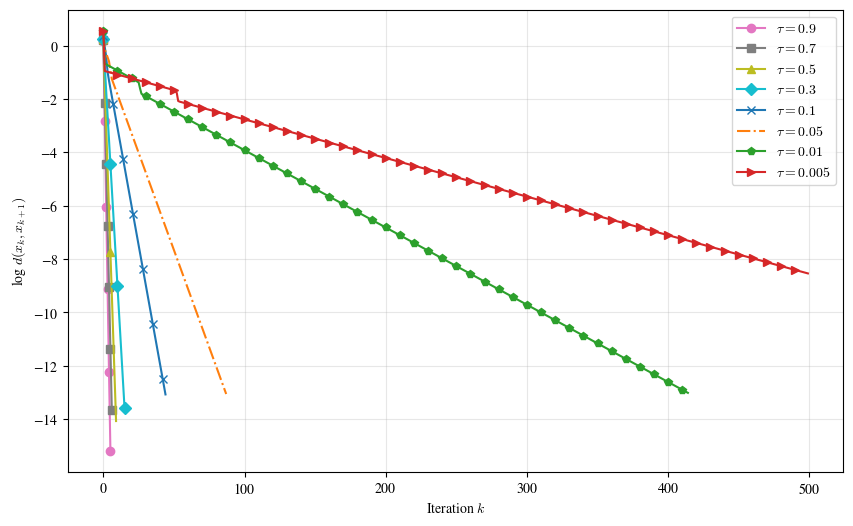

In [5]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])  # no-latex avoids LaTeX dependency



styles = ["-o", "-s", "-^", "-D", "-x", "-.", "-p", "->"]        
colors = [f"C{i+6}" for i in range(len(taus)+10)] 
#colors = plt.cm.Blues(np.linspace(0.9, 0.2, len(taus)))  # avoid too-white and too-dark 
freq = [1, 1, 5, 5, 7, 10, 10,10]
plt.figure(figsize=(10,6))       
for i in range(len(sequences)):
    outer_seq = [x[-1] for x in sequences[i]]
    distances = [np.log10(space.dist(outer_seq[j], outer_seq[j+1])) for j in range(len(outer_seq)-1)]
    plt.plot(distances, styles[i], color=colors[i], markevery=freq[i], label=rf'$\tau={taus[i]}$')


plt.xlabel(r'Iteration $k$')
plt.ylabel(r'log $d(x_{k} , x_{k+1})$')
#plt.title('Convergence of SPD iterates')
plt.legend()
plt.grid(True, alpha=0.3)
#plt.show()
plt.savefig("/Users/mahshid/Documents/git/treespace/Mahshid/Latex/images/BHV_iterates.png", 
bbox_inches="tight",
dpi=1000
)

In [9]:
# sorted samples without diameter bound to see the lower and upper bound of diameters. 
D = []
for d in range(100):
    space = BHVSpace(n_labels=5)
    S = space.sample(n_samples=20)
    prox = Prox(space=space)
    D.append(space.diameter(S)[0])


print(np.sort(D))   

[ 5.59413     6.21419223  6.45895764  6.58524212  6.64709588  6.68832914
  6.73060334  6.73380408  6.83690549  6.86623964  6.87005822  6.92323376
  7.00244253  7.00477148  7.02127335  7.05309911  7.09148157  7.11905407
  7.17109429  7.17265456  7.18000769  7.21294039  7.32770308  7.45156729
  7.50924204  7.57557974  7.63739039  7.64180916  7.65354894  7.71153017
  7.72952961  7.74304908  7.79646791  7.8021285   7.82544256  7.83119712
  7.90223229  7.90245974  7.98957248  8.0233996   8.03463443  8.07116439
  8.12623774  8.13226317  8.13680218  8.14121531  8.15470875  8.17721404
  8.200596    8.23679348  8.37486537  8.39890357  8.41091207  8.41912645
  8.44957609  8.4910226   8.50132028  8.53204083  8.56747346  8.57535829
  8.57954603  8.60745382  8.60786372  8.64135765  8.65428099  8.79693129
  8.81413625  8.84505608  8.95527773  8.99944508  9.05370611  9.16389152
  9.17394664  9.21730567  9.30940227  9.33570531  9.35512102  9.35580318
  9.36169835  9.465308    9.54295741  9.54611301  9

Sample diameter:  8.401867219922453
  step length    diameter    {step length/diameter}
-------------  ----------  ------------------------
        0.9     2.59749                    0.346489
        0.7     2.00978                    0.348297
        0.5     1.47246                    0.339568
        0.3     0.916842                   0.32721
        0.1     0.299502                   0.333887
        0.05    0.150874                   0.331403
        0.01    0.0302756                  0.330299
        0.005   0.0151418                  0.330212


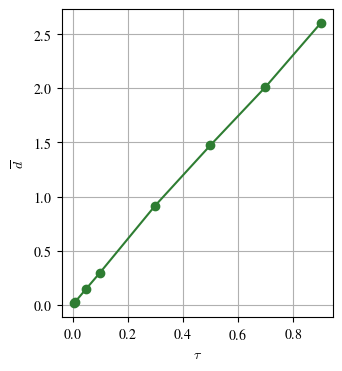

In [11]:
#example of comparing final diameter and step length for one sample
import matplotlib.pyplot as plt
from tabulate import tabulate
S = space.sample(n_samples=20)
sample_d, _ = space.diameter(S)
print("Sample diameter: ", sample_d)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
diams = [space.diameter(s[-1])[0] for s in sequences]
ratios = [taus[i]/diams[i] for i in range(len(diams))]
plt.figure(figsize=(3.5,4))
plt.plot(taus, diams, marker='o',color='#2e7d32' )
#plt.plot(taus, ratios, marker='o', color='#7b1fa2')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\overline{d}$')
#plt.title('Comparing final diameter and step length')
plt.grid(True)
#plt.show()
plt.savefig(
    "/Users/mahshid/Documents/git/treespace/Mahshid/Latex/images/spd_ratio.png",
    bbox_inches="tight",
    dpi=1000
)   

rows = list(zip(taus, diams, ratios))
print(tabulate(rows, headers=["step length", "diameter", "{step length/diameter}"]))

In [16]:
# produce the whole data first and then compute subsets in each diameter, centered at the first random data
import matplotlib.pyplot as plt
from tabulate import tabulate
import tqdm
space = BHVSpace(n_labels=5)
data_diam = [5, 7, 10, 15, 20, 23, 25, 30, 35]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for d in tqdm.tqdm(data_diam):

    S = space.sample(n_samples=20)
    sample_d, _ = space.diameter(S)
    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": d, "sample_d": sample_d, "diams": diams, "ratios": ratios})


100%|██████████| 9/9 [02:48<00:00, 18.74s/it]


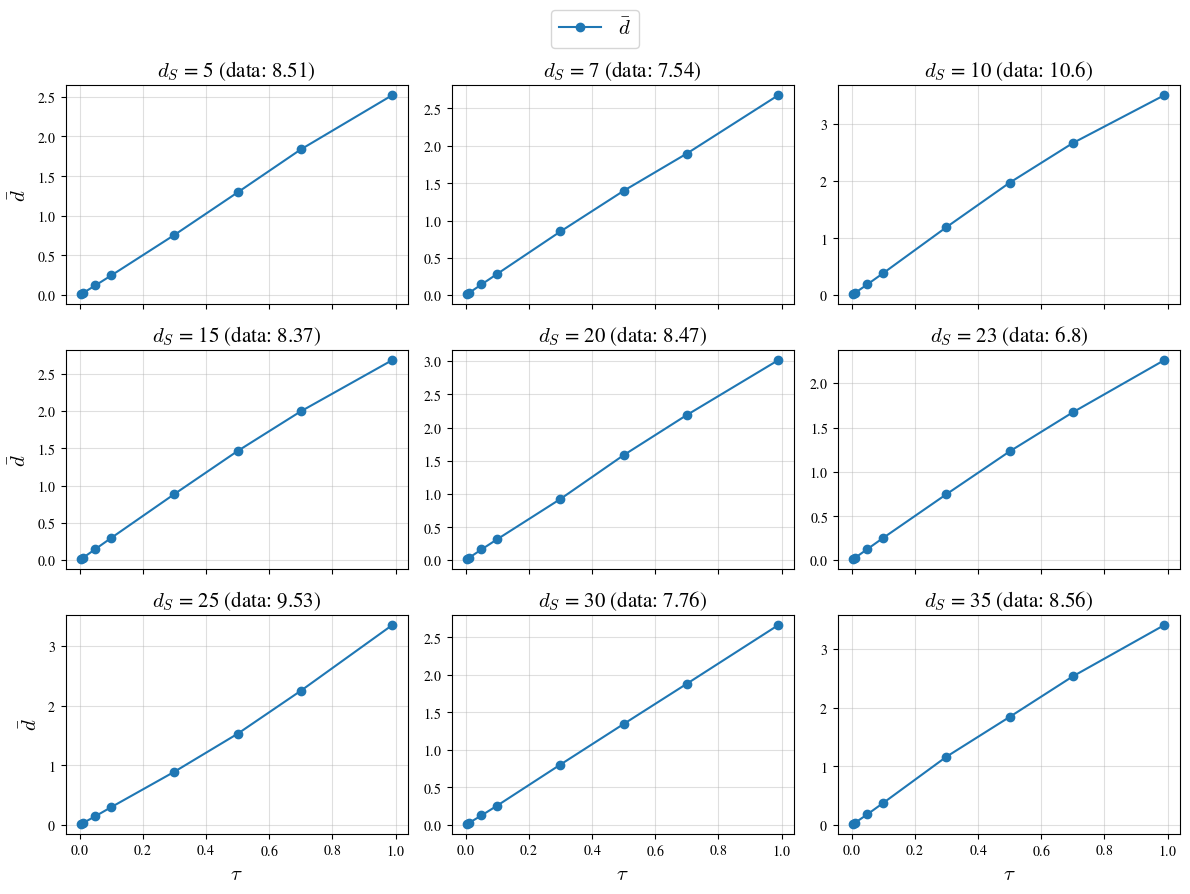

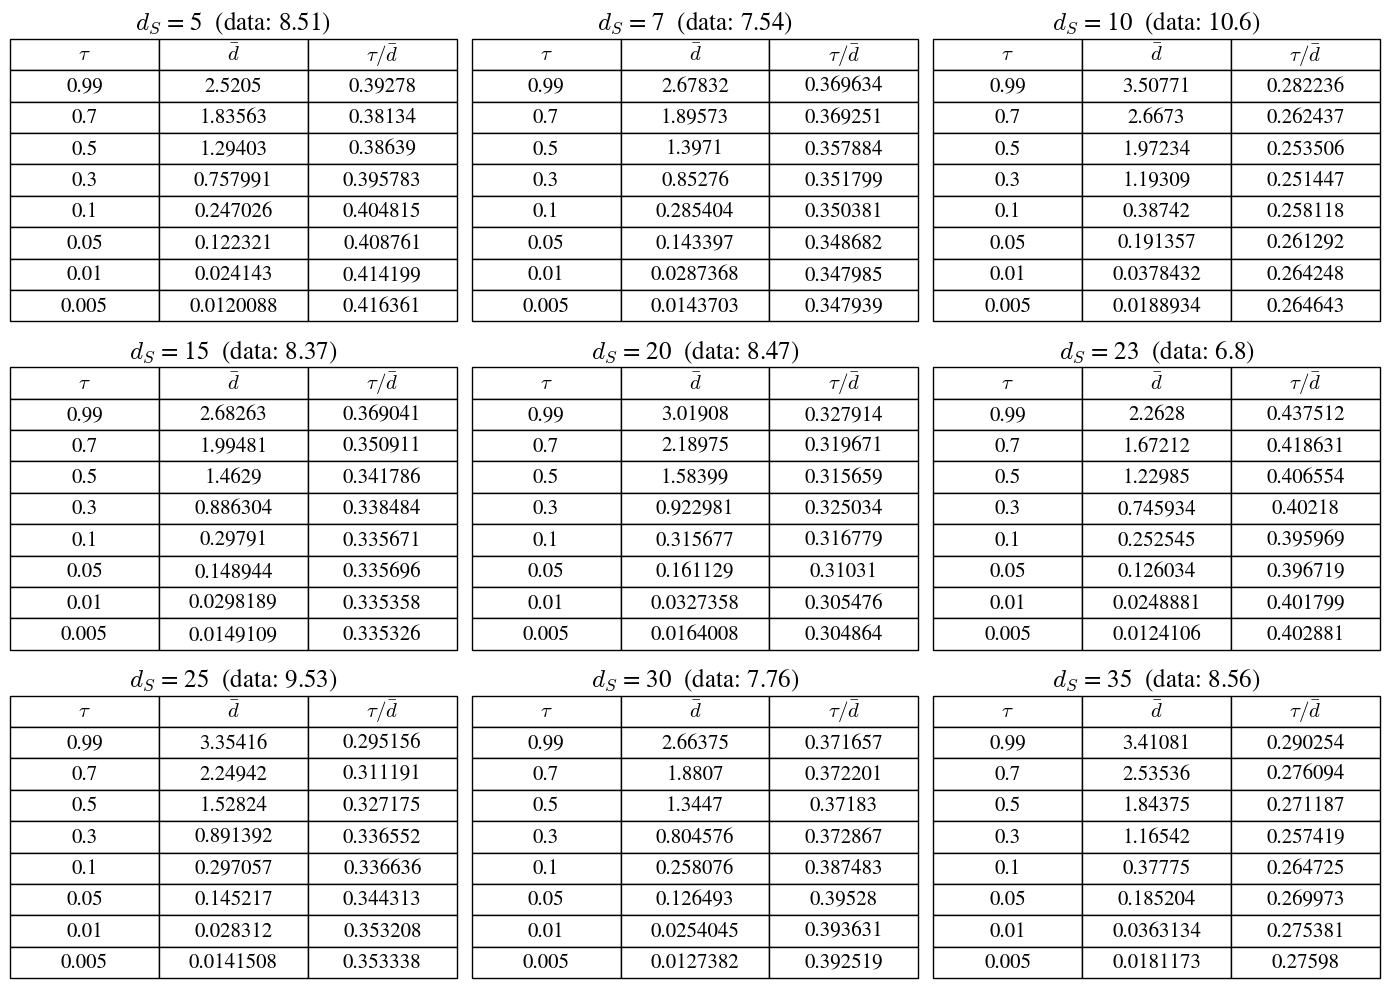

In [17]:

# --------- figure 1: 3x3 plots ----------
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()


for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(taus, r["diams"], marker="o", label=r"$\bar{d}$")
    #ax.plot(taus, r["ratios"], marker="o", label=r"$\tau/\bar{d}$")
    ax.grid(True, alpha=0.4)
    ax.set_title(fr"$d_S$ = {r['d']} (data: {r['sample_d']:.3g})", fontsize=15)

for ax in axes[6:]:
    ax.set_xlabel(r"$\tau$", fontsize=15)
for ax in axes[0::3]:
    ax.set_ylabel(r"$\bar{d}$", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_plot.png", bbox_inches="tight")
plt.show()

# --------- figure 2: 3x3 tables ----------
figT, axesT = plt.subplots(3, 3, figsize=(14, 10))
axesT = axesT.ravel()

col_labels = [r"$\tau$", r"$\bar{d}$", r"$\tau/\bar{d}$"]


for i, r in enumerate(results):
    ax = axesT[i]
    ax.axis("off")
    ax.set_title(fr"$d_S$ = {r['d']}  (data: {r['sample_d']:.3g})", fontsize=18)

    # format numbers nicely
    cell_text = [
        [f"{taus[j]:.3g}", f"{r['diams'][j]:.6g}", f"{r['ratios'][j]:.6g}"]
        for j in range(len(taus))
    ]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(15)
    tbl.scale(1, 1.5)  # (scale on width, scale on height) 

figT.tight_layout()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_table.png", bbox_inches="tight")

plt.show()
